In [1]:
import pandas as pd 

df = pd.read_csv(r"C:\Users\shrey\OneDrive\Desktop\retail-demand-forecasting\data\processed\train_cleaned.csv")
df['Date'] = pd.to_datetime(df['Date'])

df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 421570 entries, 0 to 421569
Data columns (total 16 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   Store         421570 non-null  int64         
 1   Dept          421570 non-null  int64         
 2   Date          421570 non-null  datetime64[us]
 3   Weekly_Sales  421570 non-null  float64       
 4   Temperature   421570 non-null  float64       
 5   Fuel_Price    421570 non-null  float64       
 6   MarkDown1     421570 non-null  float64       
 7   MarkDown2     421570 non-null  float64       
 8   MarkDown3     421570 non-null  float64       
 9   MarkDown4     421570 non-null  float64       
 10  MarkDown5     421570 non-null  float64       
 11  CPI           421570 non-null  float64       
 12  Unemployment  421570 non-null  float64       
 13  Type          421570 non-null  str           
 14  Size          421570 non-null  int64         
 15  IsHoliday     421570 non-nul

,Store,Dept,Date,Weekly_Sales,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Size
count,421570.000000,421570.000000,421570,421570.000000,421570.000000,421570.000000,421570.000000,421570.000000,421570.000000,421570.000000,421570.000000,421570.000000,421570.000000,421570.000000
mean,22.200546,44.260317,2011-06-18 08:30:31.963375,15981.258123,60.090059,3.361027,2590.074819,879.974298,468.087665,1083.132268,1662.772385,171.201947,7.960289,136727.915739
min,1.000000,1.000000,2010-02-05 00:00:00,-4988.940000,-2.060000,2.472000,0.000000,-265.760000,-29.100000,0.000000,0.000000,126.064000,3.879000,34875.000000
25%,11.000000,18.000000,2010-10-08 00:00:00,2079.650000,46.680000,2.933000,0.000000,0.000000,0.000000,0.000000,0.000000,132.022667,6.891000,93638.000000
50%,22.000000,37.000000,2011-06-17 00:00:00,7612.030000,62.090000,3.452000,0.000000,0.000000,0.000000,0.000000,0.000000,182.318780,7.866000,140167.000000
75%,33.000000,74.000000,2012-02-24 00:00:00,20205.852500,74.280000,3.738000,2809.050000,2.200000,4.540000,425.290000,2168.040000,212.416993,8.572000,202505.000000
max,45.000000,99.000000,2012-10-26 00:00:00,693099.360000,100.140000,4.468000,88646.760000,104519.540000,141630.610000,67474.850000,108519.280000,227.232807,14.313000,219622.000000
std,12.785297,30.492054,NaN,22711.183519,18.447931,0.458515,6052.385934,5084.538801,5528.873453,3894.529945,4207.629321,39.159276,1.863296,60980.583328


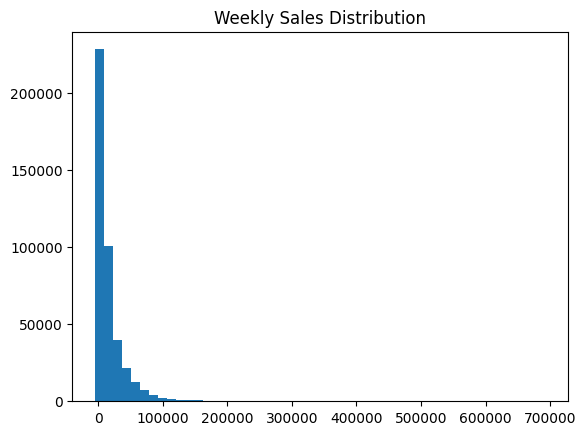

In [2]:
# UNIVARIATE ANALYSIS
# Target Variable analysis 
df['Weekly_Sales'].describe()

import matplotlib.pyplot as plt

plt.hist(df['Weekly_Sales'], bins=50)
plt.title("Weekly Sales Distribution")
plt.show()                                  # RIGHT SKEWED DISTRIBUTION, MAY NEED LOG TRANSFORMATION

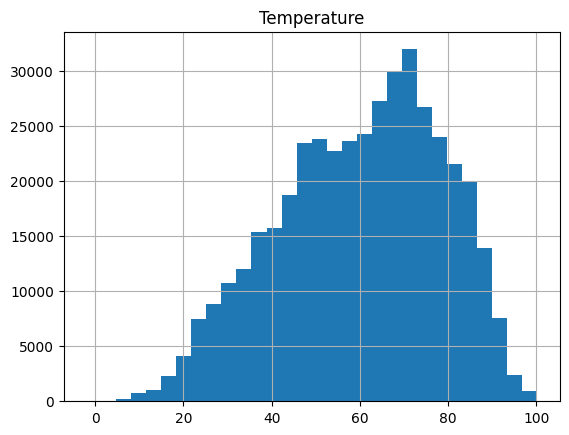

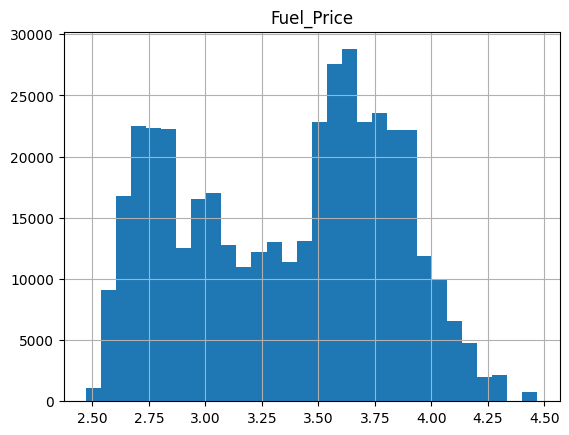

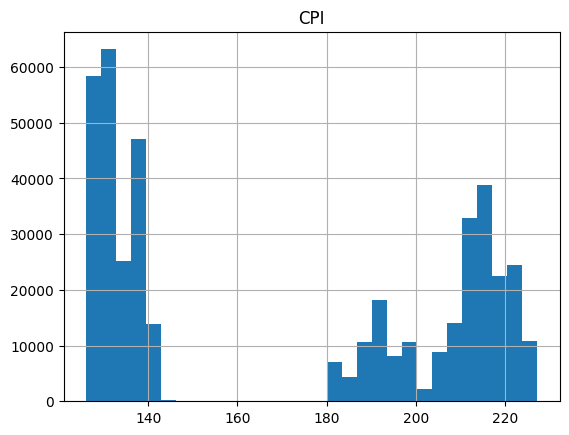

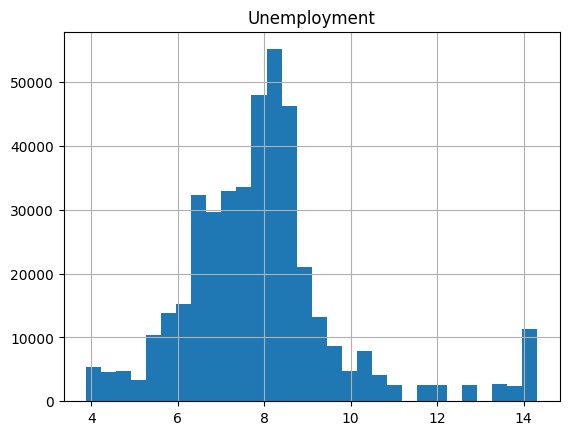

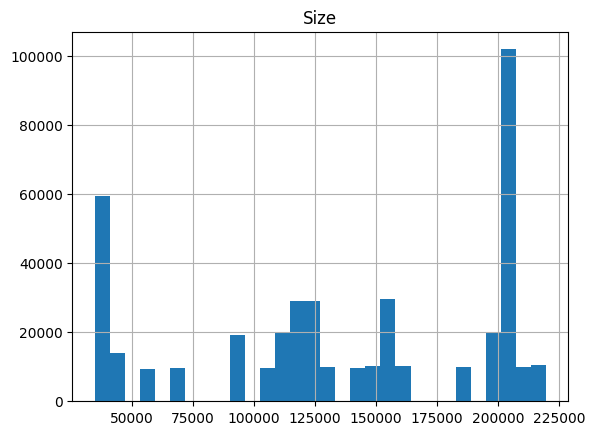

In [3]:
# Numrical analysis - only key ones 

num_cols = ['Temperature', 'Fuel_Price', 'CPI', 'Unemployment', 'Size']

for col in num_cols:
    df[col].hist(bins=30)
    plt.title(col)
    plt.show()

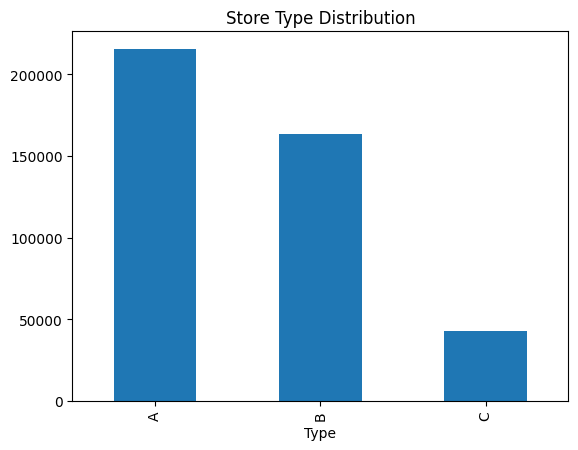

In [4]:
# Categorical analysis 

# Store Type 

df['Type'].value_counts().plot(kind='bar')
plt.title("Store Type Distribution")
plt.show()

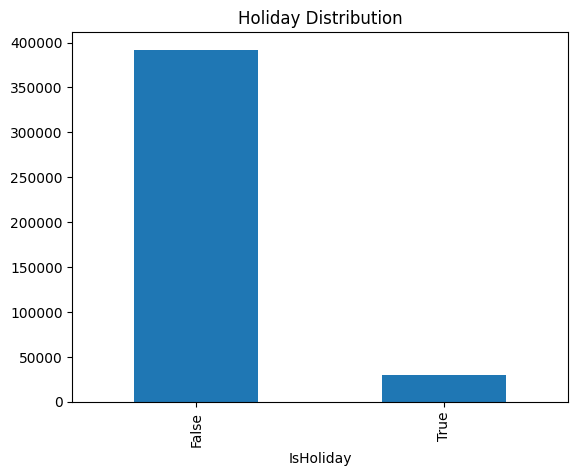

In [ ]:
# Holiday 

df['IsHoliday'].value_counts().plot(kind='bar')
plt.title("Holiday Distribution")
plt.show()

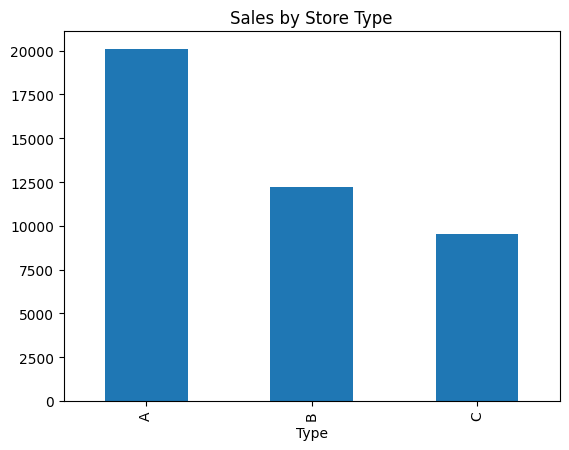

In [ ]:
# BIVARIANT ANALYSIS 

# Sales vs store type # Strong feature 

df.groupby('Type')['Weekly_Sales'].mean().plot(kind='bar')
plt.title("Sales by Store Type")
plt.show()

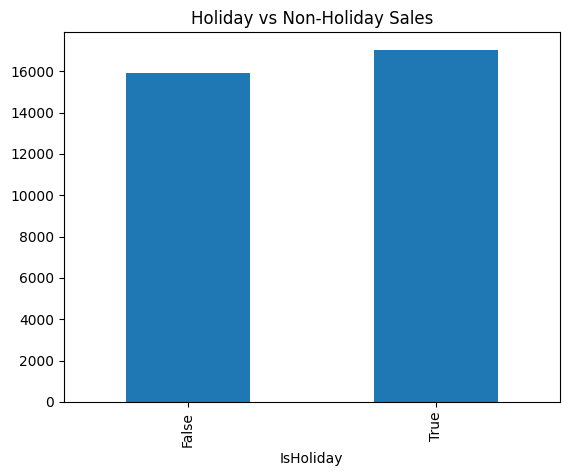

In [ ]:
# Sales vs Holiday #Useful but not single handly 
df.groupby('IsHoliday')['Weekly_Sales'].mean().plot(kind='bar')
plt.title("Holiday vs Non-Holiday Sales")
plt.show()   

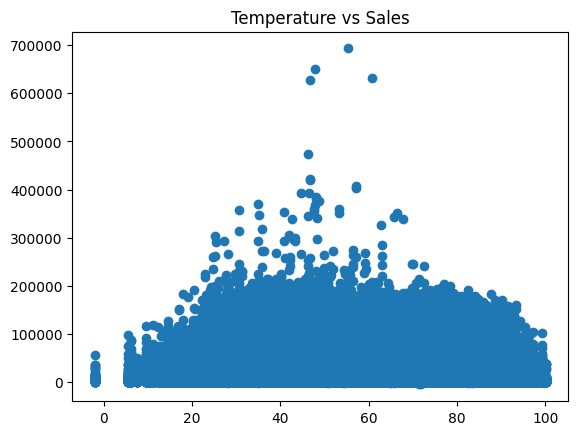

In [8]:
# Sales vs Temperature 

plt.scatter(df['Temperature'], df['Weekly_Sales'])
plt.title("Temperature vs Sales")
plt.show()

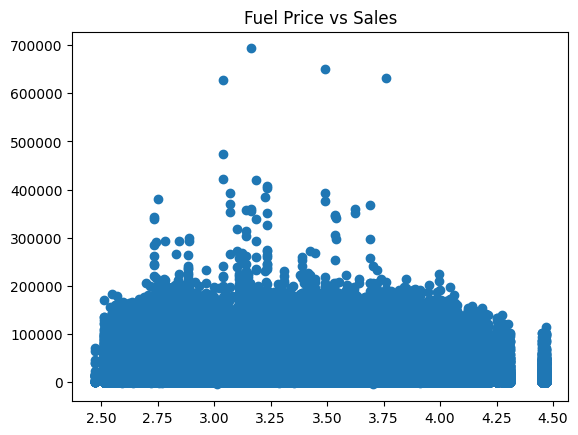

In [9]:
# Sales vs Fuel Price 
plt.scatter(df['Fuel_Price'], df['Weekly_Sales'])
plt.title("Fuel Price vs Sales")
plt.show()

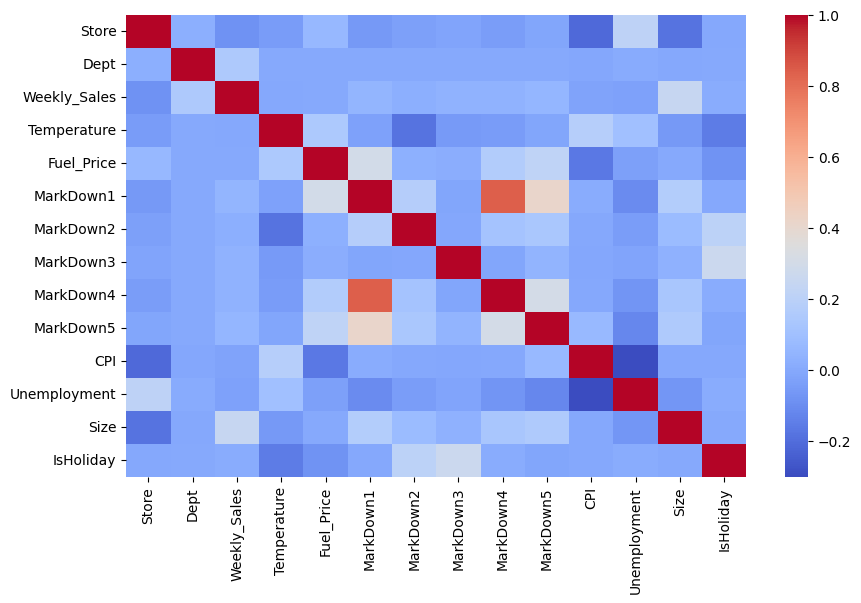

In [10]:
#COrelation matrix
import seaborn as sns

plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), cmap='coolwarm')
plt.show()